# **Projet AARN : Deep Learning for Crop Classification Using Multi-Source Satellite Data**
# **Part 3: InceptTAE-CovLF**
----------------------------------------------
**Prepared by CHEMLAL Mohamed Mounir**



# **IncepTAE-CovLF: IncepTAE with Late Covariate Fusion**

This code implements the final Part 3 model.

In [ ]:
# IncepTAE-CovLF setup
import os
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if "data_path" not in globals():
    data_path = os.environ.get("AARN_DATA_PATH", "/content/drive/MyDrive/AARN_Projet/AdditionalData")
if "model_path" not in globals():
    model_path = os.environ.get("AARN_MODEL_PATH", "/content/drive/MyDrive/AARN_Projet/Models")

os.makedirs(model_path, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

BATCH_SIZE_INCEPTAE = 32
EPOCHS_INCEPTAE = 40
INITIAL_LR_INCEPTAE = 5e-4

CLASS_NAMES = {
    1: "Corn",
    2: "Cotton",
    3: "Rice",
    5: "Soybeans",
    61: "Fallow/Idle Cropland",
    66: "Cherries",
    69: "Grapes",
    71: "Other Tree Crops",
    72: "Citrus",
    74: "Alfalfa",
    75: "Almonds",
    121: "Developed/Open Space",
    204: "Pistachios",
    999: "Others",
}

print("Data path:", data_path)
print("Model path:", model_path)
print("IncepTAE-CovLF setup OK")


Data path: drive/MyDrive/AARN_Projet/AdditionalData
Model path: drive/MyDrive/AARN_Projet/Models
IncepTAE-CovLF setup OK


# **Data Loading for IncepTAE-CovLF**

In [ ]:
expected_covariate_files = {
    "cal1": os.path.join(data_path, "california/region1/covariates_CaliforniaRegion1.csv"),
    "cal2": os.path.join(data_path, "california/region2/covariates_CaliforniaRegion2.csv"),
    "ark1": os.path.join(data_path, "arkansas/region1/covariates_ArkansasRegion1.csv"),
    "ark2": os.path.join(data_path, "arkansas/region2/covariates_ArkansasRegion2.csv"),
}

missing_files = [path for path in expected_covariate_files.values() if not os.path.exists(path)]
if missing_files:
    message = "\n".join([
        "Some required covariate CSV files were not found.",
        f"Current data_path: {data_path}",
        "Missing files:",
        *[f"- {path}" for path in missing_files],
        "",
        "Fix: mount Google Drive in Colab, or set AARN_DATA_PATH to the AdditionalData folder before running this notebook.",
    ])
    raise FileNotFoundError(message)

cov_cal1 = pd.read_csv(expected_covariate_files["cal1"])
cov_cal2 = pd.read_csv(expected_covariate_files["cal2"])
cov_ark1 = pd.read_csv(expected_covariate_files["ark1"])
cov_ark2 = pd.read_csv(expected_covariate_files["ark2"])


def clean_covariate_df(df):
    return df.drop(columns=[".geo", "system:index"], errors="ignore")

cov_cal1 = clean_covariate_df(cov_cal1)
cov_cal2 = clean_covariate_df(cov_cal2)
cov_ark1 = clean_covariate_df(cov_ark1)
cov_ark2 = clean_covariate_df(cov_ark2)

cov_cal1["region"] = "california1"
cov_cal2["region"] = "california2"
cov_ark1["region"] = "arkansas1"
cov_ark2["region"] = "arkansas2"

covlf_dataset = pd.concat([cov_cal1, cov_cal2, cov_ark1, cov_ark2], ignore_index=True)

print("Covariate dataset shape:", covlf_dataset.shape)
display(covlf_dataset.head())


Covariate dataset shape: (16350, 583)


,0_B11,0_B12,0_B2,0_B3,0_B4,0_B5,0_B6,0_B7,0_B8,0_B8A,...,9_total_precipitation_sum,9_u_component_of_wind_10m,9_v_component_of_wind_10m,cropland,soil_oc,soil_ph,topo_aspect,topo_elev,topo_slope,region
0,0.2174,0.1754,0.0446,0.0526,0.0712,0.0861,0.1122,0.1247,0.1502,0.1514,...,6.868146e-07,0.679674,-0.970596,72,2,78,252.198822,111,6.045152,california1
1,0.2371,0.2155,0.0426,0.0512,0.0696,0.0866,0.0913,0.1085,0.1202,0.1306,...,6.868146e-07,0.679674,-0.970596,69,2,76,202.555603,114,3.010167,california1
2,0.2176,0.1655,0.0582,0.0700,0.0920,0.1263,0.1517,0.1721,0.1824,0.2025,...,6.868146e-07,0.679674,-0.970596,71,2,78,231.249451,113,1.481448,california1
3,0.2439,0.2090,0.0522,0.0637,0.0780,0.1377,0.1420,0.1610,0.1570,0.1704,...,6.868146e-07,0.648932,-0.855196,121,2,75,90.000000,122,1.156021,california1
4,0.1817,0.1397,0.0391,0.0526,0.0679,0.0957,0.1224,0.1407,0.1622,0.1659,...,6.868146e-07,0.679674,-0.970596,71,2,77,51.252171,111,2.961093,california1


# **Data Cleaning**
same as part 1

In [ ]:
threshold = 0.02 * len(covlf_dataset)
class_counts = covlf_dataset["cropland"].value_counts()
small_classes = class_counts[class_counts < threshold].index

covlf_dataset["cropland"] = covlf_dataset["cropland"].apply(
    lambda x: 999 if x in small_classes else x
)

print("Class distribution after minority grouping:")
print(covlf_dataset["cropland"].value_counts().rename(index=CLASS_NAMES))

rice_samples = covlf_dataset[covlf_dataset["cropland"] == 3]
if len(rice_samples) >= 5000:
    to_remove = rice_samples.sample(n=5000, random_state=SEED)
    covlf_dataset = covlf_dataset.drop(to_remove.index).reset_index(drop=True)
else:
    print(f"Only {len(rice_samples)} Rice samples found, so no 5000-sample removal was applied.")

print("\nClass distribution after Rice balancing:")
print(covlf_dataset["cropland"].value_counts().rename(index=CLASS_NAMES))
print("\nRegion distribution:")
print(covlf_dataset["region"].value_counts())


Class distribution after minority grouping:
cropland
Rice        8644
Soybeans    2907
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64

Class distribution after Rice balancing:
cropland
Rice        3644
Soybeans    2907
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64

Region distribution:
region
arkansas1      4297
california2    3362
arkansas2      2500
california1    1191
Name: count, dtype: int64


# **Input Preparation**
input is two branches :
- temporal branch: Sentinel-2 + climate, expected shape (N, 36, 16);
- static branch: soil + topography, expected shape (N, 5).

In [ ]:
sentinel_band_suffixes = ["_B2", "_B3", "_B4", "_B5", "_B6", "_B7", "_B8", "_B8A", "_B11", "_B12"]
climate_suffixes = [
    "climate_pet",
    "climate_pr",
    "climate_tmmn",
    "climate_tmmx",
    "temperature_2m",
    "temperature_2m_max",
    "temperature_2m_min",
    "total_precipitation_sum",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
]

sentinel_cols = [c for c in covlf_dataset.columns if any(c.endswith(b) for b in sentinel_band_suffixes)]
climate_cols = [c for c in covlf_dataset.columns if any(c.endswith(s) for s in climate_suffixes)]
soil_cols = [c for c in covlf_dataset.columns if c.startswith("soil_")]
topo_cols = [c for c in covlf_dataset.columns if c.startswith("topo_")]
static_cols = soil_cols + topo_cols


def temporal_prefix(col):
    try:
        return int(col.split("_")[0])
    except ValueError as exc:
        raise ValueError(f"Column '{col}' no prefix") from exc


sentinel_cols = sorted(sentinel_cols, key=temporal_prefix)
climate_cols = sorted(climate_cols, key=temporal_prefix)

print("Sentinel columns:", len(sentinel_cols))
print("Climate columns:", len(climate_cols))
print("Soil columns:", len(soil_cols))
print("Topography columns:", len(topo_cols))
print("Static covariates:", static_cols)

n_samples = len(covlf_dataset)

X_covlf_sentinel = (
    covlf_dataset[sentinel_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .values
    .astype(np.float32)
    .reshape(n_samples, 36, 10)
)


X_covlf_climate = (
    covlf_dataset[climate_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .values
    .astype(np.float32)
    .reshape(n_samples, 36, 6)
)

X_covlf_soil = covlf_dataset[soil_cols].apply(pd.to_numeric, errors="coerce").values.astype(np.float32)
X_covlf_topo = covlf_dataset[topo_cols].apply(pd.to_numeric, errors="coerce").values.astype(np.float32)

X_covlf_temporal = np.concatenate([X_covlf_sentinel, X_covlf_climate], axis=2)
X_covlf_static = np.concatenate([X_covlf_soil, X_covlf_topo], axis=1)

y_covlf = covlf_dataset["cropland"].values
covlf_label_encoder = LabelEncoder()
y_covlf_encoded = covlf_label_encoder.fit_transform(y_covlf)
num_classes_covlf = len(covlf_label_encoder.classes_)
class_names_covlf = [CLASS_NAMES.get(code, str(code)) for code in covlf_label_encoder.classes_]

print("X_covlf_sentinel shape:", X_covlf_sentinel.shape)
print("X_covlf_climate shape:", X_covlf_climate.shape)
print("X_covlf_temporal shape:", X_covlf_temporal.shape)
print("X_covlf_static shape:", X_covlf_static.shape)
print("Number of classes:", num_classes_covlf)
print("Class names:", class_names_covlf)


Sentinel columns: 360
Climate columns: 216
Soil columns: 2
Topography columns: 3
Static covariates: ['soil_oc', 'soil_ph', 'topo_aspect', 'topo_elev', 'topo_slope']
X_covlf_sentinel shape: (11350, 36, 10)
X_covlf_climate shape: (11350, 36, 6)
X_covlf_temporal shape: (11350, 36, 16)
X_covlf_static shape: (11350, 5)
Number of classes: 6
Class names: ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Grapes', 'Others']


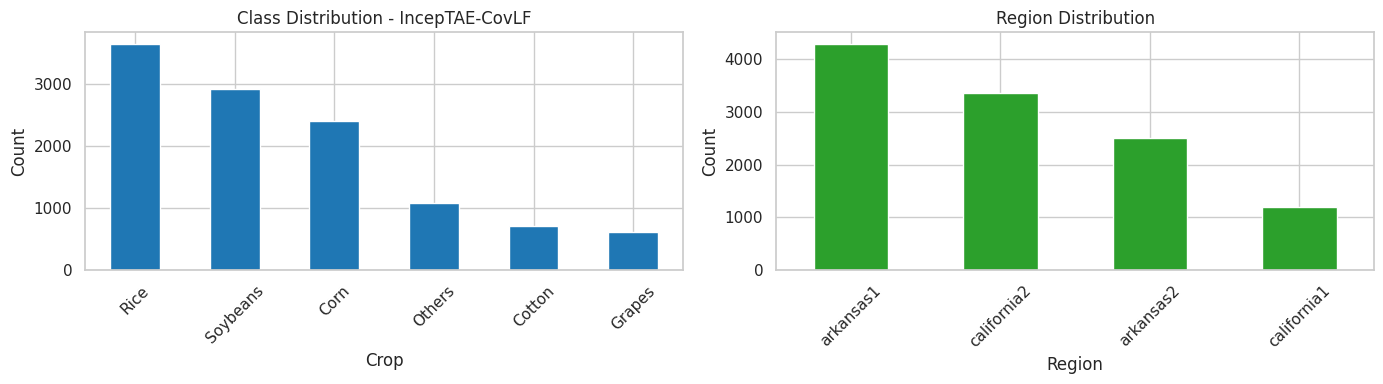

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

class_counts_named = covlf_dataset["cropland"].value_counts().rename(index=CLASS_NAMES)
class_counts_named.plot(kind="bar", ax=axes[0], color="#1f77b4")
axes[0].set_title("Class Distribution - IncepTAE-CovLF")
axes[0].set_xlabel("Crop")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

covlf_dataset["region"].value_counts().plot(kind="bar", ax=axes[1], color="#2ca02c")
axes[1].set_title("Region Distribution")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# **Train / Validation / Test Split**

In [ ]:
covlf_indices = np.arange(len(covlf_dataset))
covlf_class_region_key = covlf_dataset["cropland"].astype(str) + "_" + covlf_dataset["region"].astype(str)

if covlf_class_region_key.value_counts().min() >= 5:
    covlf_stratify = covlf_class_region_key.reset_index(drop=True)
    covlf_stratification_used = "class + region"
else:
    covlf_stratify = pd.Series(y_covlf_encoded)
    covlf_stratification_used = "class only"

covlf_train_val_idx, covlf_test_idx = train_test_split(
    covlf_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=covlf_stratify,
)

covlf_second_stratify = covlf_stratify.iloc[covlf_train_val_idx]
if covlf_second_stratify.value_counts().min() < 2:
    covlf_second_stratify = pd.Series(y_covlf_encoded).iloc[covlf_train_val_idx]
    covlf_stratification_used = covlf_stratification_used + " then class only for validation"

covlf_train_idx, covlf_val_idx = train_test_split(
    covlf_train_val_idx,
    test_size=0.20,
    random_state=SEED,
    stratify=covlf_second_stratify,
)

print("Stratification used:", covlf_stratification_used)
print("Train:", len(covlf_train_idx), "Val:", len(covlf_val_idx), "Test:", len(covlf_test_idx))
print("Ratios:", len(covlf_train_idx)/len(covlf_dataset), len(covlf_val_idx)/len(covlf_dataset), len(covlf_test_idx)/len(covlf_dataset))


Stratification used: class + region
Train: 7264 Val: 1816 Test: 2270
Ratios: 0.64 0.16 0.2


# **Scaling and Class Weights**
adding normalization with scalers and class weights

In [ ]:
X_covlf_temporal_train = X_covlf_temporal[covlf_train_idx]
X_covlf_temporal_val = X_covlf_temporal[covlf_val_idx]
X_covlf_temporal_test = X_covlf_temporal[covlf_test_idx]

X_covlf_static_train = X_covlf_static[covlf_train_idx]
X_covlf_static_val = X_covlf_static[covlf_val_idx]
X_covlf_static_test = X_covlf_static[covlf_test_idx]

y_covlf_train = y_covlf_encoded[covlf_train_idx]
y_covlf_val = y_covlf_encoded[covlf_val_idx]
y_covlf_test = y_covlf_encoded[covlf_test_idx]

covlf_temporal_scaler = StandardScaler()
train_shape = X_covlf_temporal_train.shape
val_shape = X_covlf_temporal_val.shape
test_shape = X_covlf_temporal_test.shape

X_covlf_temporal_train = covlf_temporal_scaler.fit_transform(
    X_covlf_temporal_train.reshape(train_shape[0], -1)
).reshape(train_shape).astype(np.float32)
X_covlf_temporal_val = covlf_temporal_scaler.transform(
    X_covlf_temporal_val.reshape(val_shape[0], -1)
).reshape(val_shape).astype(np.float32)
X_covlf_temporal_test = covlf_temporal_scaler.transform(
    X_covlf_temporal_test.reshape(test_shape[0], -1)
).reshape(test_shape).astype(np.float32)

static_train_df = pd.DataFrame(X_covlf_static_train, columns=static_cols)
static_val_df = pd.DataFrame(X_covlf_static_val, columns=static_cols)
static_test_df = pd.DataFrame(X_covlf_static_test, columns=static_cols)

static_medians = static_train_df.median(numeric_only=True)
static_train_df = static_train_df.fillna(static_medians)
static_val_df = static_val_df.fillna(static_medians)
static_test_df = static_test_df.fillna(static_medians)

covlf_static_scaler = StandardScaler()
X_covlf_static_train = covlf_static_scaler.fit_transform(static_train_df).astype(np.float32)
X_covlf_static_val = covlf_static_scaler.transform(static_val_df).astype(np.float32)
X_covlf_static_test = covlf_static_scaler.transform(static_test_df).astype(np.float32)

covlf_class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_covlf_train),
    y=y_covlf_train,
)
covlf_class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y_covlf_train), covlf_class_weight_values)
}

print("X_covlf_temporal_train:", X_covlf_temporal_train.shape)
print("X_covlf_static_train:", X_covlf_static_train.shape)
print("Class weights:", covlf_class_weights)


X_covlf_temporal_train: (7264, 36, 16)
X_covlf_static_train: (7264, 5)
Class weights: {0: 0.7866580030322721, 1: 2.6608058608058607, 2: 0.51915380217267, 3: 0.6508960573476702, 4: 3.120274914089347, 5: 1.7545893719806764}


# **IncepTAE-CovLF Architecture**

In [ ]:
def make_group_norm(name=None):
    group_norm = getattr(layers, "GroupNormalization", None)
    if group_norm is not None:
        return group_norm(groups=1, axis=-1, name=name)
    return layers.LayerNormalization(axis=-1, name=name)


def date_based_positional_encoding(day_positions, d_model, num_heads, tau=1000.0):
    day_positions = tf.cast(day_positions[:, tf.newaxis], tf.float32)
    dims = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
    head_dim = d_model // num_heads

    channel_in_head = tf.math.floormod(tf.cast(dims, tf.int32), head_dim)
    channel_in_head = tf.cast(channel_in_head, tf.float32)
    pair_index = tf.floor(channel_in_head / 2.0)

    scale = tf.pow(tf.cast(tau, tf.float32), (2.0 * pair_index) / tf.cast(head_dim, tf.float32))
    phase = (np.pi / 2.0) * tf.cast(tf.math.floormod(tf.cast(channel_in_head, tf.int32), 2), tf.float32)
    return tf.sin(day_positions / scale + phase)


class IncepTAEBlock(layers.Layer):
    def __init__(self, d_model=304, num_heads=16, d_k=8, pool_k=5, dropout=0.15,
                 max_time_steps=36, day_step=10, tau=1000.0, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_k
        self.pool_k = pool_k
        self.tau = tau
        self.day_positions = tf.constant(np.arange(max_time_steps, dtype="float32") * day_step, dtype=tf.float32)

        self.norm = make_group_norm(name="input_group_norm")
        self.embed = layers.Conv1D(d_model, kernel_size=1, padding="same", use_bias=False)
        self.q_group_conv = layers.Conv1D(num_heads * d_k, 1, padding="same", groups=num_heads, use_bias=False)
        self.avg_pool = layers.AveragePooling1D(pool_size=pool_k, strides=1, padding="same")
        self.k_group_conv = layers.Conv1D(num_heads * d_k, 1, padding="same", groups=num_heads, use_bias=False)
        self.max_pool = layers.MaxPooling1D(pool_size=pool_k, strides=1, padding="same")
        self.v_dense = layers.Dense(num_heads * d_k, use_bias=False)
        self.attn_dropout = layers.Dropout(dropout)
        self.temporal_mlp = keras.Sequential([
            layers.Dense(d_model, activation="relu"),
            layers.Dropout(dropout),
            layers.Dense(d_model // 2, activation="relu"),
        ], name="inceptae_temporal_mlp")

    def call(self, x, training=False):
        batch_size = tf.shape(x)[0]
        time_steps = tf.shape(x)[1]

        z = self.embed(self.norm(x))
        pe = date_based_positional_encoding(
            self.day_positions[:time_steps],
            self.d_model,
            self.num_heads,
            tau=self.tau,
        )
        z = z + pe[tf.newaxis, :, :]

        q = self.q_group_conv(z)
        q = tf.reduce_mean(q, axis=1)
        q = tf.reshape(q, (batch_size, self.num_heads, 1, self.d_k))

        k = self.k_group_conv(self.avg_pool(z))
        k = tf.reshape(k, (batch_size, time_steps, self.num_heads, self.d_k))
        k = tf.transpose(k, perm=[0, 2, 1, 3])

        v = self.v_dense(self.max_pool(z))
        v = tf.reshape(v, (batch_size, time_steps, self.num_heads, self.d_k))
        v = tf.transpose(v, perm=[0, 2, 1, 3])

        logits = tf.matmul(q, k, transpose_b=True) / tf.sqrt(tf.cast(self.d_k, tf.float32))
        weights = tf.nn.softmax(logits, axis=-1)
        weights = self.attn_dropout(weights, training=training)

        out = tf.matmul(weights, v)
        out = tf.squeeze(out, axis=2)
        out = tf.reshape(out, (batch_size, self.num_heads * self.d_k))
        return self.temporal_mlp(out, training=training)


def build_inceptae_covlf_model(T=36, d_in=16, n_static=5, n_classes=6,
                               d_model=304, num_heads=16, d_k=8, pool_k=5, dropout=0.15):
    temporal_input = keras.Input(shape=(T, d_in), name="temporal_ts")
    static_input = keras.Input(shape=(n_static,), name="static_covariates")

    temporal_features = IncepTAEBlock(
        d_model=d_model,
        num_heads=num_heads,
        d_k=d_k,
        pool_k=pool_k,
        dropout=dropout,
        max_time_steps=T,
        day_step=10,
        name="inceptae_block",
    )(temporal_input)

    static_features = keras.Sequential([
        layers.LayerNormalization(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(16, activation="relu"),
    ], name="static_mlp")(static_input)

    x = layers.Concatenate(name="late_fusion")([temporal_features, static_features])
    x = layers.Dense(64, activation="relu", name="fusion_dense")(x)
    x = layers.Dropout(dropout)(x)
    output = layers.Dense(n_classes, activation="softmax", name="crop_classifier")(x)

    return keras.Model(
        inputs=[temporal_input, static_input],
        outputs=output,
        name="IncepTAE_CovLateFusion",
    )

keras.backend.clear_session()
inceptae_model = build_inceptae_covlf_model(
    T=36,
    d_in=X_covlf_temporal_train.shape[2],
    n_static=X_covlf_static_train.shape[1],
    n_classes=num_classes_covlf,
)

inceptae_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR_INCEPTAE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

inceptae_model.summary()


Model: "IncepTAE_CovLateFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temporal_ts         │ (None, 36, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_covariates   │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inceptae_block      │ (None, 152)       │    134,248 │ temporal_ts[0][0] │
│ (IncepTAEBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_mlp          │ (None, 16)        │        730 │ static_covariate… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion         │ (None, 168)       │          0 │ inceptae_block[0… │
│ (Concatenate)       │                   │            │ static_mlp[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 64)        │     10,816 │ late_fusion[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ fusion_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_classifier     │ (None, 6)         │        390 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146,184 (571.03 KB)

 Trainable params: 146,184 (571.03 KB)

 Non-trainable params: 0 (0.00 B)

# **Training**

In [ ]:
inceptae_train_inputs = {
    "temporal_ts": X_covlf_temporal_train,
    "static_covariates": X_covlf_static_train,
}
inceptae_val_inputs = {
    "temporal_ts": X_covlf_temporal_val,
    "static_covariates": X_covlf_static_val,
}
inceptae_test_inputs = {
    "temporal_ts": X_covlf_temporal_test,
    "static_covariates": X_covlf_static_test,
}

best_inceptae_file = os.path.join(model_path, "best_IncepTAE_CovLF.keras")

inceptae_callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        best_inceptae_file,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

start_train = time.perf_counter()
inceptae_history = inceptae_model.fit(
    x=inceptae_train_inputs,
    y=y_covlf_train,
    validation_data=(inceptae_val_inputs, y_covlf_val),
    epochs=EPOCHS_INCEPTAE,
    batch_size=BATCH_SIZE_INCEPTAE,
    callbacks=inceptae_callbacks,
    class_weight=covlf_class_weights,
    verbose=1,
)
inceptae_training_time = time.perf_counter() - start_train
inceptae_seconds_per_epoch = inceptae_training_time / len(inceptae_history.history["loss"])

print(f"Training time: {inceptae_training_time:.2f} seconds")
print(f"Seconds per epoch: {inceptae_seconds_per_epoch:.2f}")
print("Best checkpoint:", best_inceptae_file)


Epoch 1/40
220/227 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4777 - loss: 1.2956
Epoch 1: val_loss improved from None to 0.54050, saving model to drive/MyDrive/AARN_Projet/Models/best_IncepTAE_CovLF.keras

Epoch 1: finished saving model to drive/MyDrive/AARN_Projet/Models/best_IncepTAE_CovLF.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.6005 - loss: 1.0044 - val_accuracy: 0.7450 - val_loss: 0.5405 - learning_rate: 5.0000e-04
Epoch 2/40
219/227 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8216 - loss: 0.4826
Epoch 2: val_loss improved from 0.54050 to 0.44046, saving model to drive/MyDrive/AARN_Projet/Models/best_IncepTAE_CovLF.keras

Epoch 2: finished saving model to drive/MyDrive/AARN_Projet/Models/best_IncepTAE_CovLF.keras
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8578 - loss: 0.4138 - val_accuracy: 0.8172 - val_loss: 0.4405 - learning_rate: 5.0000e-04
Epoch 3/40
225/227 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9041 - loss: 0.3154
Epoch 3: va

# **Training Curves**

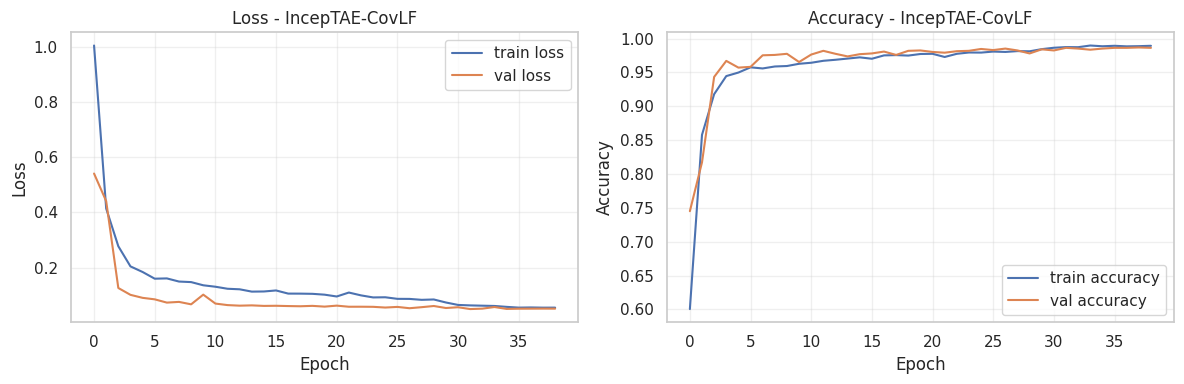

In [ ]:
history_df = pd.DataFrame(inceptae_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["loss"], label="train loss")
axes[0].plot(history_df["val_loss"], label="val loss")
axes[0].set_title("Loss - IncepTAE-CovLF")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["accuracy"], label="train accuracy")
axes[1].plot(history_df["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy - IncepTAE-CovLF")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# **Evaluation**

In [ ]:
inceptae_test_loss, inceptae_test_accuracy = inceptae_model.evaluate(
    inceptae_test_inputs,
    y_covlf_test,
    verbose=0,
)

start_inference = time.perf_counter()
inceptae_pred_probs = inceptae_model.predict(
    inceptae_test_inputs,
    batch_size=512,
    verbose=1,
)
inceptae_inference_time = time.perf_counter() - start_inference
inceptae_inference_ms_per_sample = 1000 * inceptae_inference_time / len(y_covlf_test)

inceptae_y_pred = np.argmax(inceptae_pred_probs, axis=1)

inceptae_oa = accuracy_score(y_covlf_test, inceptae_y_pred)
inceptae_kappa = cohen_kappa_score(y_covlf_test, inceptae_y_pred)
inceptae_macro_f1 = f1_score(y_covlf_test, inceptae_y_pred, average="macro")

print("Test loss:", round(float(inceptae_test_loss), 4))
print("Test accuracy:", round(float(inceptae_test_accuracy), 4))
print(f"OA: {inceptae_oa:.3f} | Kappa: {inceptae_kappa:.3f} | Macro F1: {inceptae_macro_f1:.3f}")
print(f"Inference time: {inceptae_inference_time:.2f} seconds")
print(f"Inference speed: {inceptae_inference_ms_per_sample:.4f} ms/sample")


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 342ms/step
Test loss: 0.0597
Test accuracy: 0.9819
OA: 0.982 | Kappa: 0.977 | Macro F1: 0.966
Inference time: 3.03 seconds
Inference speed: 1.3330 ms/sample


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


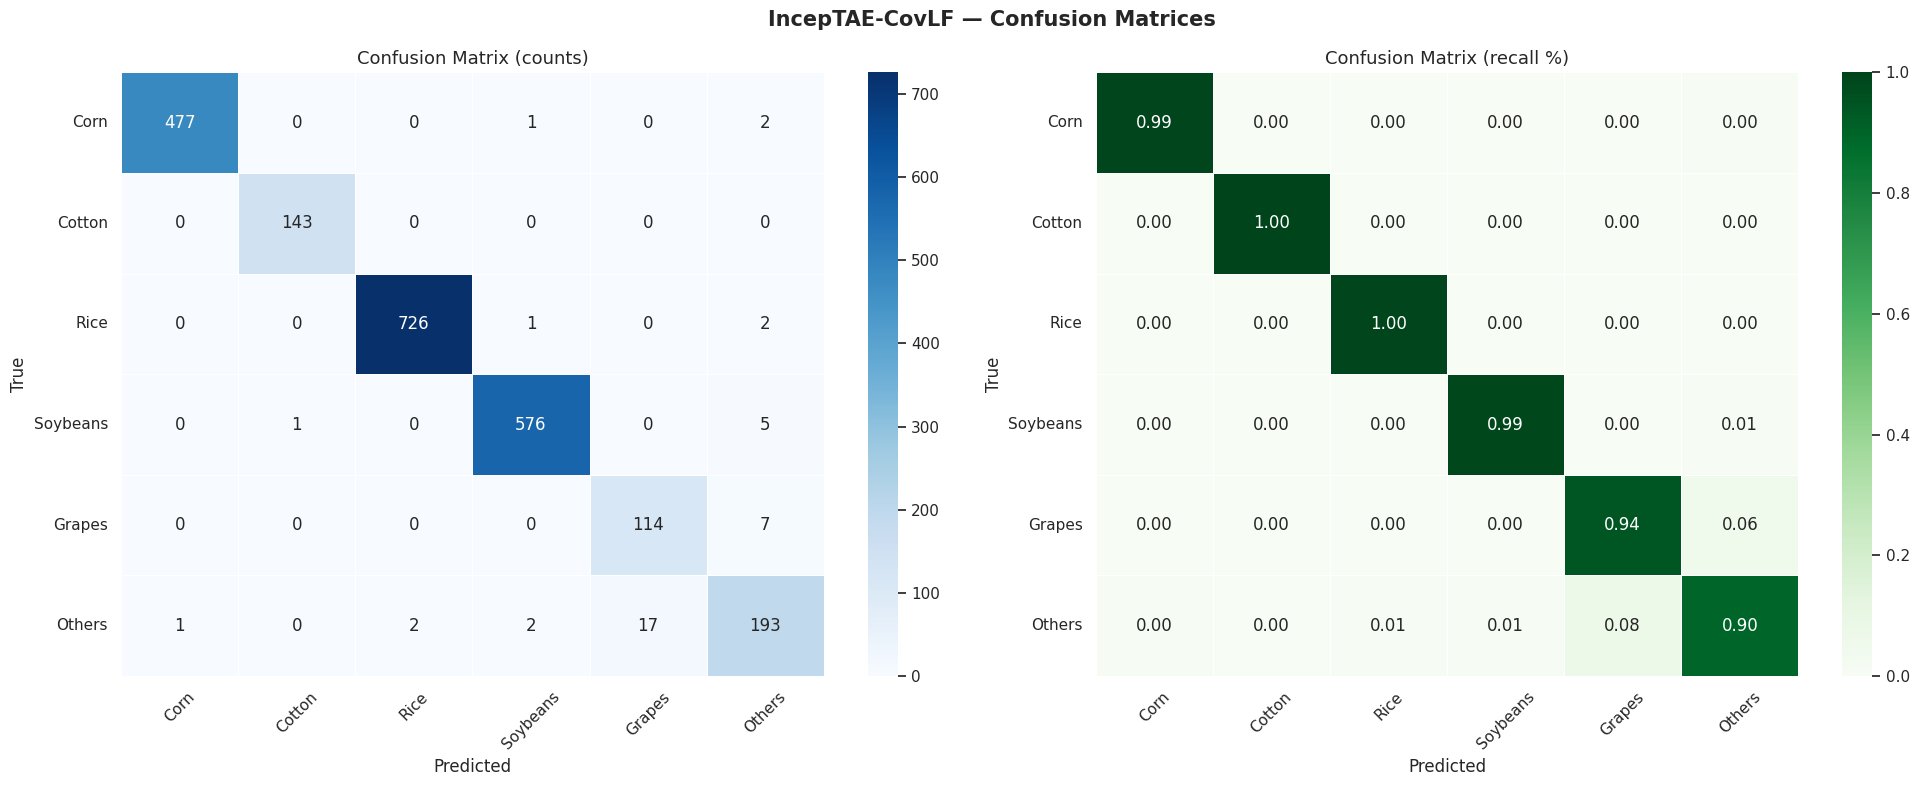

OA: 0.9819383259911895
Kappa: 0.976579151997705
Macro F1: 0.9659070027300146


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score, f1_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_proba = inceptae_model.predict(inceptae_test_inputs)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_covlf_test

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Row-normalized confusion matrix (recall by class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Absolute confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=class_names_covlf,
    yticklabels=class_names_covlf,
    linewidths=0.5,
    linecolor="white"
)
axes[0].set_title("Confusion Matrix (counts)", fontsize=13)
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Normalized confusion matrix
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    ax=axes[1],
    xticklabels=class_names_covlf,
    yticklabels=class_names_covlf,
    linewidths=0.5,
    linecolor="white"
)
axes[1].set_title("Confusion Matrix (recall %)", fontsize=13)
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle("IncepTAE-CovLF — Confusion Matrices", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Metrics
oa = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("OA:", oa)
print("Kappa:", kappa)
print("Macro F1:", macro_f1)


In [ ]:
# Save IncepTAE-CovLF model
inceptae_final_file = os.path.join(model_path, "IncepTAE_CovLateFusion_Part3.keras")
inceptae_model.save(inceptae_final_file)
print("Saved model:", inceptae_final_file)


Saved model: drive/MyDrive/AARN_Projet/Models/IncepTAE_CovLateFusion_Part3.keras
